# Single Sphere

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0s = 2 * np.pi * np.linspace(1 / 700, 1 / 300, 200)
materials = [treams.Material(16 + 0.5j), treams.Material()]
lmax = 4
radius = 75
spheres = [treams.TMatrix.sphere(lmax, k0, radius, materials) for k0 in k0s]

In [4]:
xs_sca = np.array([tm.xs_sca_avg for tm in spheres]) / (np.pi * radius ** 2)
xs_ext = np.array([tm.xs_ext_avg for tm in spheres]) / (np.pi * radius ** 2)

In [5]:
swb_lmax1 = treams.SphericalWaveBasis.default(1)
spheres_lmax1 = [tm[swb_lmax1] for tm in spheres]
xs_sca_lmax1 = np.array([tm.xs_sca_avg for tm in spheres_lmax1]) / (np.pi * radius ** 2)
xs_ext_lmax1 = np.array([tm.xs_ext_avg for tm in spheres_lmax1]) / (np.pi * radius ** 2)

In [6]:
tm = spheres[-1]
inc = treams.plane_wave([0, 0, tm.k0], 1, k0=tm.k0, material=tm.material)
sca = tm @ inc.expand(tm.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:555: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(


In [7]:
x = np.linspace(-100, 100, 101)
y = 0
z = np.linspace(-100, 100, 101)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [8]:
intensity = np.zeros_like(xx)
valid = tm.valid_points(grid, [radius])
intensity[~valid] = np.nan
intensity[valid] = 0.5 * np.sum(
    np.abs(inc.efield(grid[valid]) + sca.efield(grid[valid])) ** 2, -1
)

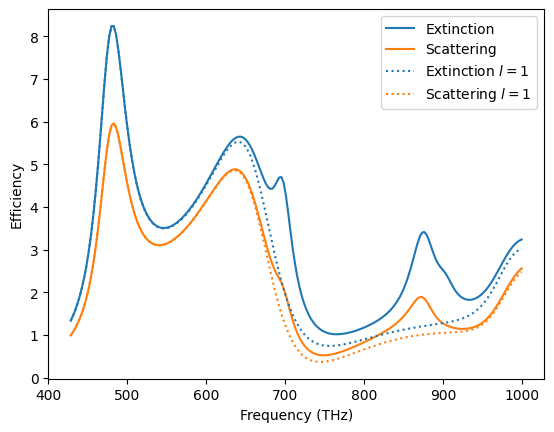

In [9]:
fig, ax = plt.subplots()
ax.plot(k0s * 299792.458 / (2 * np.pi), xs_ext)
ax.plot(k0s * 299792.458 / (2 * np.pi), xs_sca)
ax.plot(k0s * 299792.458 / (2 * np.pi), xs_ext_lmax1, color="C0", linestyle=":")
ax.plot(k0s * 299792.458 / (2 * np.pi), xs_sca_lmax1, color="C1", linestyle=":")
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Efficiency")
ax.legend(["Extinction", "Scattering", "Extinction $l=1$", "Scattering $l=1$"])
fig.show()

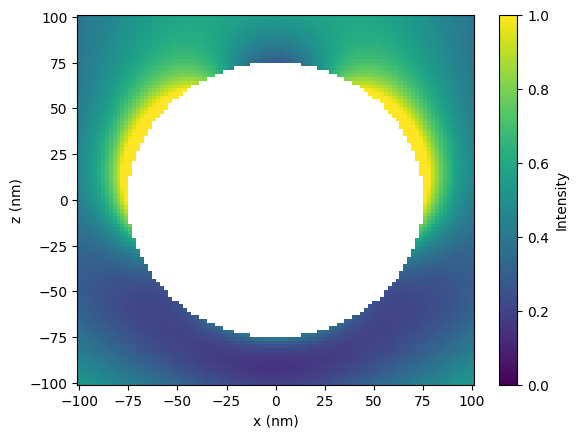

In [10]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, zz, intensity, shading="nearest", vmin=0, vmax=1,
)
cb = plt.colorbar(pcm)
cb.set_label("Intensity")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
fig.show()